# Importação Módulos Necessários

In [57]:
from statsmodels.tsa.seasonal import seasonal_decompose
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Leitura Dos Dados

In [58]:
dados = pd.read_csv('dados_troposfera_MGBH.csv')

In [59]:
dados.head()

,*SITE,___EPOCH____,TROTOT,_SIG,TRWET,TGETOT,_SIG.1,TGNTOT,_SIG.2,WVAPOR,_SIG.3,MTEMP,data_completa,ds_mes,nm_ano
0,MGBH,09:002:00000,2323.1,6.7,264.3,-0.59,1.01,0.29,1.10,42.56,1.08,282.5,2009-01-02 00:00:00,01/2009,2009
1,MGBH,09:002:00300,2322.8,6.5,263.9,-0.58,1.00,0.30,1.09,42.51,1.04,282.5,2009-01-02 00:05:00,01/2009,2009
2,MGBH,09:002:00600,2322.0,6.3,263.2,-0.55,0.98,0.31,1.08,42.39,1.02,282.5,2009-01-02 00:10:00,01/2009,2009
3,MGBH,09:002:00900,2321.3,6.2,262.6,-0.53,0.97,0.32,1.06,42.29,0.99,282.6,2009-01-02 00:15:00,01/2009,2009
4,MGBH,09:002:01200,2320.9,6.0,262.1,-0.51,0.96,0.33,1.05,42.21,0.97,282.6,2009-01-02 00:20:00,01/2009,2009


Correção do tipo de dados

In [60]:
dados['data_completa'] = pd.to_datetime(dados['data_completa'])

In [61]:
dados['data'] = pd.to_datetime(dados['data_completa'].dt.date)

## Verificação de registros null e registros não capturados

### Verificação valores null

In [62]:
dados['TRWET'].isnull().sum()

np.int64(0)

In [63]:
dados['TRWET'].isna().sum()

np.int64(0)

In [64]:
mask = dados['TRWET'] == 0.0
dados[mask]

,*SITE,___EPOCH____,TROTOT,_SIG,TRWET,TGETOT,_SIG.1,TGNTOT,_SIG.2,WVAPOR,_SIG.3,MTEMP,data_completa,ds_mes,nm_ano,data


Não foi identificado nenhum registro nullo o com 0

### Verificação de registros não capturados

Como a coleta é feita de 5 em 5 minutos tecnicamente deveria ter 288 registros diários de acorodo com o cálculo 24 horas x 60 minutos = 1440 minutos, 1440 / 5 = 288 registros

Basicamente a verificação abaixo contabiliza a frequência diária de registros e aplica uma máscara booleana para identificar dias incompletos (com menos de 288 entradas). Esse filtro é então utilizado para isolar ou remover esses dados do DataFrame principal.

In [65]:
contagem_por_dia = dados.groupby('data').size()
mask_contagem = contagem_por_dia < 288
print("\n5 primeiros dias com contagem menor que 288:\n")
print(contagem_por_dia[mask_contagem].head())
print("\nContagem total:\n")
print(contagem_por_dia[mask_contagem].count())
print("\nMaior contagem:\n")
print(contagem_por_dia[mask_contagem].max())
print("\nMenor contagem:\n")
data_min = contagem_por_dia[mask_contagem].idxmin()
print(contagem_por_dia[mask_contagem].min())
print(data_min)


5 primeiros dias com contagem menor que 288:

data
2009-01-07    267
2009-01-08    216
2009-01-15    264
2009-01-16    276
2009-02-02    156
dtype: int64

Contagem total:

478

Maior contagem:

287

Menor contagem:

21
2018-10-20 00:00:00


Foram encontrados 478 dias com pelo menos 1 registro faltante e o dia com menor quantidade de registros foi de 21 registros no dia 2018-10-20 00:00:00

In [66]:
mask_contagem_maior = contagem_por_dia > 288
print("\n5 primeiros dias com contagem maior que 288:\n")
print(contagem_por_dia[mask_contagem_maior].head())
print("\nContagem total:\n")
print(contagem_por_dia[mask_contagem_maior].count())
print("\nMaior contagem:\n")
print(contagem_por_dia[mask_contagem_maior].max())
print("\nMenor contagem:\n")
data_min_maior = contagem_por_dia[mask_contagem_maior].idxmin()
print(contagem_por_dia[mask_contagem_maior].min())
print(data_min_maior)


5 primeiros dias com contagem maior que 288:

data
2012-01-01    575
2016-01-01    576
2020-01-01    576
2024-01-01    576
dtype: int64

Contagem total:

4

Maior contagem:

576

Menor contagem:

575
2012-01-01 00:00:00


Foram encontrados também dias com mais registros coletados do que 288. 
OBS: É necessário investigação para validar se ouve alguma duplicação de dados na origem, na coleta ou tratamento da coluna de data

In [67]:
TRWET = pd.DataFrame(dados[[ 'data_completa','TRWET']])

In [68]:
TRWET.describe()

,data_completa,TRWET
count,1738343,1.738343e+06
mean,2017-07-16 02:03:55.157217792,1.687103e+02
min,2009-01-02 00:00:00,1.230000e+01
25%,2013-04-01 03:57:30,1.154000e+02
50%,2017-06-24 11:35:00,1.665000e+02
75%,2021-10-10 08:12:30,2.223000e+02
max,2026-03-07 23:40:00,3.366000e+02
std,NaN,6.414694e+01


In [69]:
TRWET.set_index('data_completa', inplace=True)

In [70]:
TRWET.TRWET.isnull().sum()

np.int64(0)

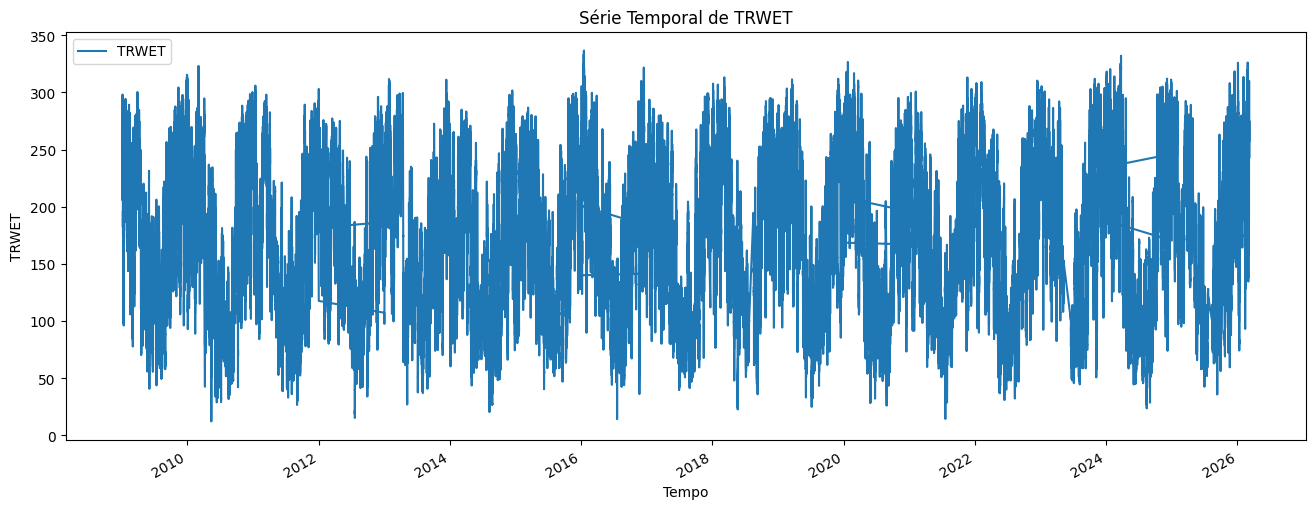

In [71]:
TRWET.plot(figsize=(16, 6))
plt.title('Série Temporal de TRWET')
plt.xlabel('Tempo')
plt.ylabel('TRWET')
plt.show()

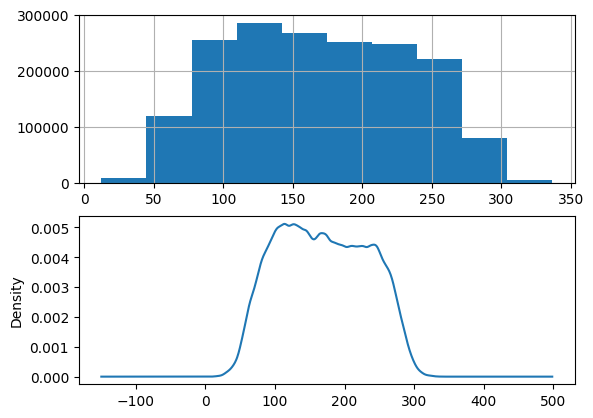

In [72]:
plt.figure(1)
plt.subplot(211)
TRWET.TRWET.hist()


plt.subplot(212)
TRWET.TRWET.plot(kind='kde')

plt.show()

Text(0, 0.5, 'TRWET')

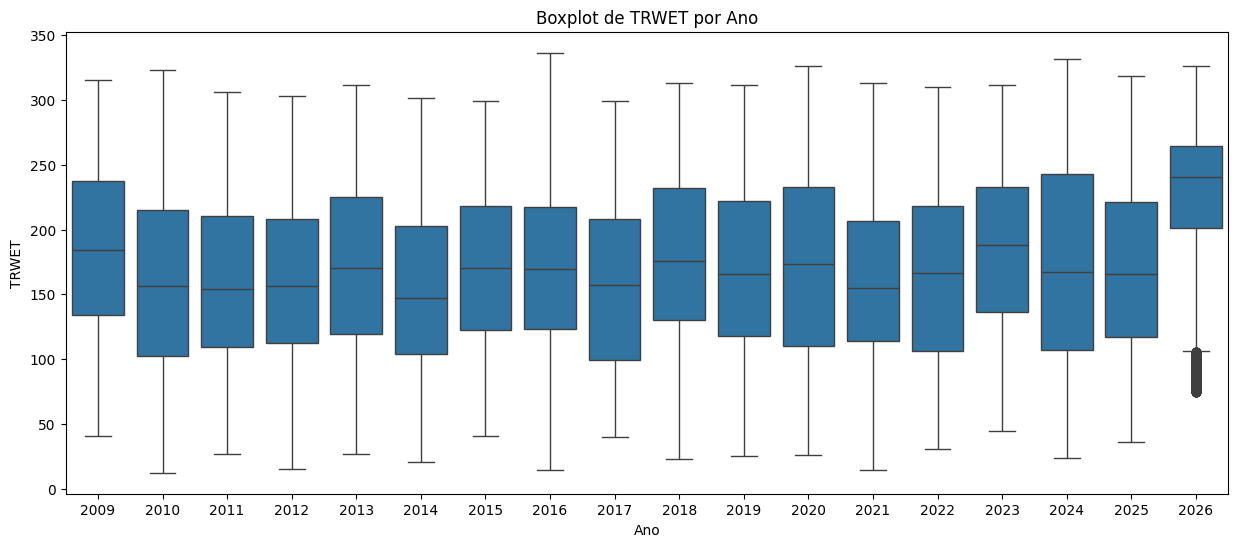

In [75]:
fig, ax = plt.subplots(figsize=(15, 6))

indice_ano = TRWET.TRWET.index.year
VALOR = TRWET.TRWET

sns.boxplot(x=indice_ano, y=VALOR, ax=ax, data = TRWET)

plt.title('Boxplot de TRWET por Ano')
plt.xlabel('Ano')
plt.ylabel('TRWET')

## Decomposição Série por coleta

In [76]:
decomposicao_multiplicativa = seasonal_decompose(TRWET, model='multiplicative',extrapolate_trend='freq' ,period=288)

In [77]:
type(decomposicao_multiplicativa)

statsmodels.tsa.seasonal.DecomposeResult

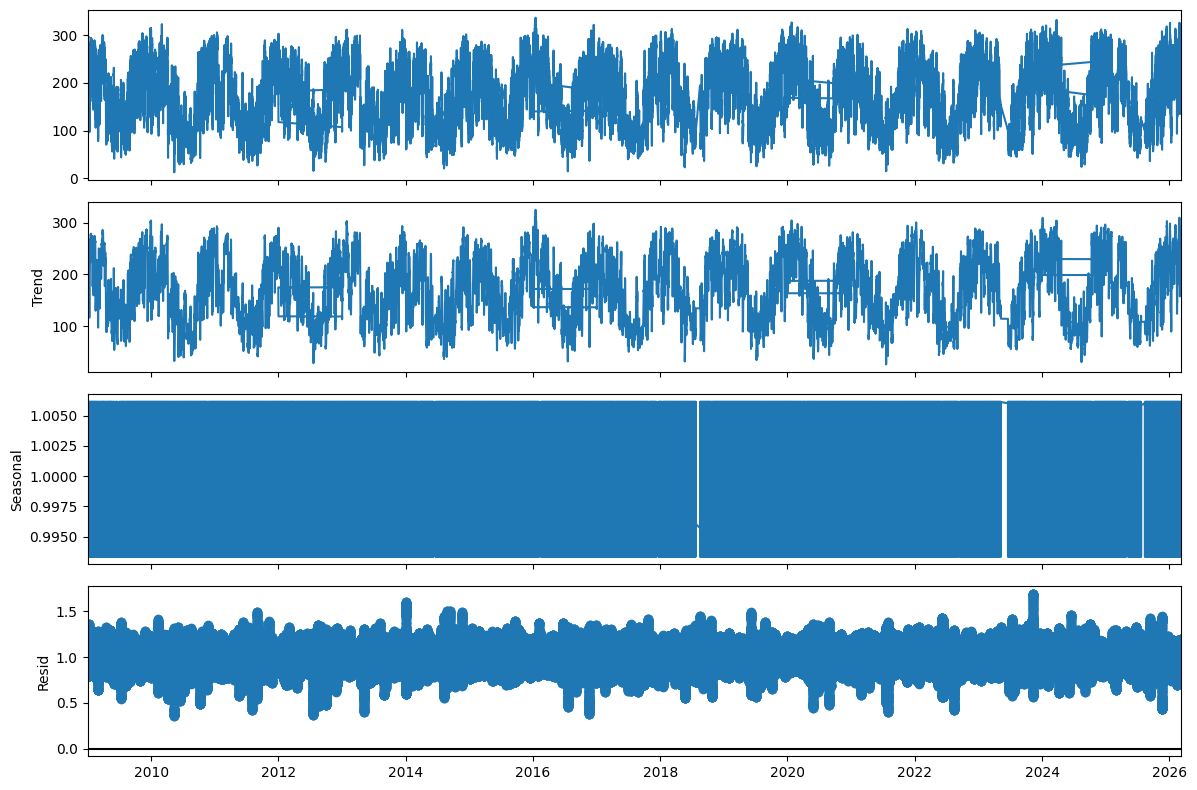

In [79]:
plt.rcParams['figure.figsize'] = (12, 8)
decomposicao_multiplicativa.plot()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ─────────────────────────────────────────
# 1. AGREGAR: 5 min → mensal
# ─────────────────────────────────────────
# Ajuste 'datetime' e 'zwd' para os nomes reais das suas colunas
dados = dados.set_index('data_completa').sort_index()

mensal = dados['TRWET'].resample('ME').mean()

# ─────────────────────────────────────────
# 2. PLOTAR
# ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(mensal.index, mensal.values,
        color='steelblue', linewidth=2, marker='o', markersize=4)

# Eixo X mostrando cada ano
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

ax.set_xlabel('Tempo')
ax.set_ylabel('ZWD (mm)')
ax.set_title('ZWD — Média Mensal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

KeyError: "None of ['data_completa'] are in the columns"

In [ ]:


decomposicao_multiplicativa = seasonal_decompose(TRWET, model='multiplicative',extrapolate_trend='freq' ,period=288)

In [73]:
#result = seasonal_decompose(TRWET, model='additive', period=12)

#result.plot()